In [1]:
from __future__ import annotations
import pandas as pd
from pathlib import Path
import copy

from collections import defaultdict
from typing import Any, Dict, Iterable, List, Optional, Union
import math
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import seaborn as sns
sns.set_style('whitegrid')

#switch dir and load packages
import os

os.chdir(r'..\..')

from app.dike_components.dike_model import DikeModel
from app.cost_calculator import CostCalculator, DirectCostGroundWork, StructureCosts, InfrastructureCosts
from app.unit_costs_and_surcharges import load_kosten_catalogus
from dev.incremental_costs.utils import get_dimensions_dict_from_df, modified_cost_computation, make_reinforcement_incremental, compute_incremental_volumes, compute_incremental_costs, compute_lcc, lcc_plot, recategorize_cost

# Path of WJK
working_dir = Path(r"c:\Users\klerk_wj\Stichting Deltares\KIA – Aanpasbaar en Uitbreidbaar - Documents\WP3 casestudies\2c WIP casus WSSS\designs toolbox KOSWAT")
# Path of Yida
# working_dir = Path(r"C:\Users\tao\OneDrive - Stichting Deltares\KIA – Aanpasbaar en Uitbreidbaar - Documents\WP3 casestudies\2c WIP casus WSSS\designs toolbox KOSWAT")

sns.set_palette("husl", 12)
colors = sns.color_palette("husl", 12)




In [11]:
## SETTINGS ## 
files = [
    'ontwerpvariant grond gestacked/kostenoverzicht design grond 1.xlsx',
         'ontwerpvariant grond gestacked/kostenoverzicht grond 2 aanlegprofiel.xlsx',
         'ontwerpvariant grond gestacked/kostenoverzicht grond 3 aanlegprofiel.xlsx',
         'ontwerpen kruinverhogingen/kostenoverzicht 50cm.xlsx',
         'ontwerpen kruinverhogingen/kostenoverzicht 100cm.xlsx',
         'ontwerpen kruinverhogingen/kostenoverzicht 150cm.xlsx',
         'ontwerpen kruinverhogingen/kostenoverzicht 200cm.xlsx',]
names = [
"Grondversterking 2025", "Grondversterking 2075", "Grondversterking 2125",
         "Kruinverhoging 50cm", "Kruinverhoging 100cm", "Kruinverhoging 150cm", "Kruinverhoging 200cm"]

alternatives = dict(zip(names, files))

dike = DikeModel(complexity = 'gemiddelde maatregel')

#load costs for all alternatives
cost_dataframes_per_alternative = {}
for name, file in alternatives.items():
    cost_dataframes_per_alternative[name] = pd.read_excel(working_dir / file, sheet_name='Kosten')

#dimensions for all alternatives
dimensions = {}
for name, df in cost_dataframes_per_alternative.items():
    dimensions[name] = get_dimensions_dict_from_df(df)

#adjust wegoppervlakte for 2075 and 2125 to 2000 as we assume it only concerns the road:
# dimensions["Grondversterking 2075"]["infrastructure"]['Weg'] = 2000
# dimensions["Grondversterking 2125"]["infrastructure"]['Weg'] = 2000

#recomputation of plain costs for all alternatives
cost_summaries = {}
full_cost_dicts = {}
new_dimensions = {}
for name, dimension in dimensions.items():
    cost_summaries[name], full_cost_dicts[name], new_dimensions[name] = modified_cost_computation(dike, dimension)
    print(f"Kosten van beginsituatie naar {name}:")
    print(f"€{cost_summaries[name]['Kosten excl. BTW'].sum():,.0f}")

df_all_costs = pd.concat(cost_summaries.values(), axis=1)
df_all_costs.columns = cost_summaries.keys()
# print("Kosten van alle losse alternatieven:")
#add (ruw) to the column names of df_all_costs
df_all_costs.columns = [col + " (ruw)" for col in df_all_costs.columns]

cost_per_increment_summary, cost_per_increment_detailed, dimensions_per_increment = compute_incremental_costs(names, dimensions, dike)

df_all_increments = pd.concat(cost_per_increment_summary.values(), axis=1)
df_all_increments.columns = cost_per_increment_summary.keys()
df_all_increments.columns = [col + " (incrementeel)" for col in df_all_increments.columns]


#merge the incremental costs with the plain costs
df_all_costs_with_increments_soil = pd.concat([df_all_costs, df_all_increments], axis=1)
df_all_costs_with_increments_soil
#add (incrementeel) to the column names of df_all_increments before merging

# #add Vastgoedkosten 1300000 for Grondversterking 2025
# df_all_costs_with_increments.loc['Vastgoedkosten', 'Grondversterking 2025 (ruw)'] = 1300000
# df_all_costs_with_increments.loc['Vastgoedkosten', 'Grondversterking 2075 (ruw)'] = 1300000 + 100 * (250*3)
# df_all_costs_with_increments.loc['Vastgoedkosten', 'Grondversterking 2125 (ruw)'] = 1300000 + 100 * (250*3) + 100 * (250*5)

# #add grondaankoop kosten for Grondversterking 2075 and 2125:
# df_all_costs_with_increments.loc['Vastgoedkosten', 'Grondversterking 2025 (incrementeel)'] = 1300000
# df_all_costs_with_increments.loc['Vastgoedkosten', 'Grondversterking 2025 to Grondversterking 2075 (incrementeel)'] = 100 * (250*3)
# df_all_costs_with_increments.loc['Vastgoedkosten', 'Grondversterking 2075 to Grondversterking 2125 (incrementeel)'] = 100 * (250*5)

print("Kosten per versterking (ruw en incrementeel):")
df_all_costs_with_increments_soil


Kosten van beginsituatie naar Grondversterking 2025:
€1,317,010
Kosten van beginsituatie naar Grondversterking 2075:
€1,630,445
Kosten van beginsituatie naar Grondversterking 2125:
€2,125,449
Kosten van beginsituatie naar Kruinverhoging 50cm:
€1,027,465
Kosten van beginsituatie naar Kruinverhoging 100cm:
€1,242,818
Kosten van beginsituatie naar Kruinverhoging 150cm:
€1,441,529
Kosten van beginsituatie naar Kruinverhoging 200cm:
€1,633,827
Kosten van Grondversterking 2025:
€1,317,010


Incrementele kosten van Grondversterking 2025 naar Grondversterking 2075:
€1,400,548


Incrementele kosten van Grondversterking 2075 naar Grondversterking 2125:
€1,773,155


Incrementele kosten van Grondversterking 2125 naar Kruinverhoging 50cm:
€508,977


Incrementele kosten van Kruinverhoging 50cm naar Kruinverhoging 100cm:
€988,420


Incrementele kosten van Kruinverhoging 100cm naar Kruinverhoging 150cm:
€1,039,865


Incrementele kosten van Kruinverhoging 150cm naar Kruinverhoging 200cm:
€1,062,245


K

,Grondversterking 2025 (ruw),Grondversterking 2075 (ruw),Grondversterking 2125 (ruw),Kruinverhoging 50cm (ruw),Kruinverhoging 100cm (ruw),Kruinverhoging 150cm (ruw),Kruinverhoging 200cm (ruw),Grondversterking 2025 (incrementeel),Grondversterking 2025 to Grondversterking 2075 (incrementeel),Grondversterking 2075 to Grondversterking 2125 (incrementeel),Grondversterking 2125 to Kruinverhoging 50cm (incrementeel),Kruinverhoging 50cm to Kruinverhoging 100cm (incrementeel),Kruinverhoging 100cm to Kruinverhoging 150cm (incrementeel),Kruinverhoging 150cm to Kruinverhoging 200cm (incrementeel)
Directe kosten grondwerk,289055.186101,422620.963492,638300.222529,282278.139196,372795.063502,456270.577155,536335.641138,289055.186101,313398.468368,470927.830730,35948.543775,251932.532679,265443.215166,264781.403790
Directe kosten constructies,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Directe kosten infrastructuur,290005.418820,303224.166200,320016.907870,177341.356744,187502.531981,196918.789272,206648.155923,290005.418820,303224.166200,320016.907870,177341.356744,187502.531981,196918.789272,206648.155923
Directe niet-benoemde bouwkosten,37672.197465,43001.045525,51150.697463,26202.479850,29934.105103,33379.996242,36754.884826,37672.197465,39724.370671,46129.525709,18812.591988,26308.229178,27655.175382,28608.257706
Indirecte bouwkosten,217093.893530,270638.774292,355339.136001,171012.444739,207765.336089,241676.809704,274473.006352,217093.893530,231038.346465,294655.498312,81701.562819,163944.620188,172489.183407,176016.511973
Engineeringkosten,186950.389037,233060.558820,306000.268526,147267.353099,178917.102544,208119.965333,236362.407451,186950.389037,198958.653566,253742.558787,70357.294282,141180.896553,148539.046485,151576.605197
Overige bijkomende kosten,75155.935291,93692.686963,123015.183327,59202.956020,71926.473384,83666.317722,95020.063297,75155.935291,79983.378318,102007.058809,28284.339410,56756.139318,59714.189542,60935.318672
Objectoverstijgende risicoreservering,221077.251756,264206.893806,331627.000581,164160.587455,193977.172703,221496.542974,248232.595778,221077.251756,234220.272050,285675.545256,96531.731361,160794.823296,169105.614548,173678.409919
Vastgoedkosten,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [12]:
#make dataframe of dimensions
volume_cost_df_soil = pd.DataFrame.from_dict(new_dimensions, orient='index', columns = ['V1b', 'V2b', 'V3', 'V4', 'V5', 'Kosten (excl. BTW)'])

for name, dims in new_dimensions.items():
    volume_cost_df_soil.loc[name] = [dims['ground']['V1b'], dims['ground']['V2b'], dims['ground']['V3'], dims['ground']['V4'], dims['ground']['V5'], 0.]
    volume_cost_df_soil.loc[name, 'Kosten (excl. BTW)'] = df_all_costs_with_increments_soil[name + " (ruw)"].sum()

for name, dims in dimensions_per_increment.items():
    volume_cost_df_soil.loc[name] = [dims['ground']['V1b'], dims['ground']['V2b'], dims['ground']['V3'], dims['ground']['V4'], dims['ground']['V5'], 0.]
    volume_cost_df_soil.loc[name, 'Kosten (excl. BTW)'] = df_all_costs_with_increments_soil[name + " (incrementeel)"].sum()
#make all values in dimensions_df integers
volume_cost_df_soil = volume_cost_df_soil.astype(int)

#drop Grondversterking 2025
volume_cost_df_soil = volume_cost_df_soil.drop(['Grondversterking 2025'], axis=0)
#drop Grondversterking 2125 to Kruinverhoging 50cm
volume_cost_df_soil = volume_cost_df_soil.drop(['Grondversterking 2125 to Kruinverhoging 50cm'], axis=0)

#add column with cost for each alternative
volume_cost_df_soil

,V1b,V2b,V3,V4,V5,Kosten (excl. BTW)
Grondversterking 2075,2758,11032,2758,7822,6184,1630445
Grondversterking 2125,2994,11979,2994,9710,17320,2125449
Kruinverhoging 50cm,1620,6481,1620,4926,5387,1027465
Kruinverhoging 100cm,1658,6635,1658,5826,10161,1242817
Kruinverhoging 150cm,1668,6674,1668,5953,15676,1441528
Kruinverhoging 200cm,1687,6748,1687,6016,21013,1633826
Grondversterking 2025 to Grondversterking 2075,2196,5530,2758,2291,9182,1400547
Grondversterking 2075 to Grondversterking 2125,2758,7822,2994,1887,18958,1773154
Kruinverhoging 50cm to Kruinverhoging 100cm,1620,4926,1658,900,9699,988419
Kruinverhoging 100cm to Kruinverhoging 150cm,1658,5826,1668,126,11341,1039865


y = 35.35484753346291x + 322077.9547159534
y = 11471.387096774197x + 14325.854838709674


Text(0, 0.5, 'Volume (m3)')

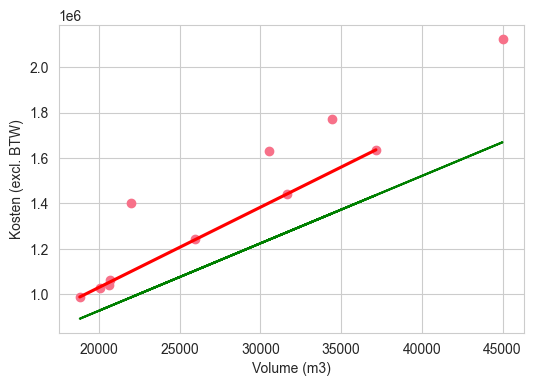

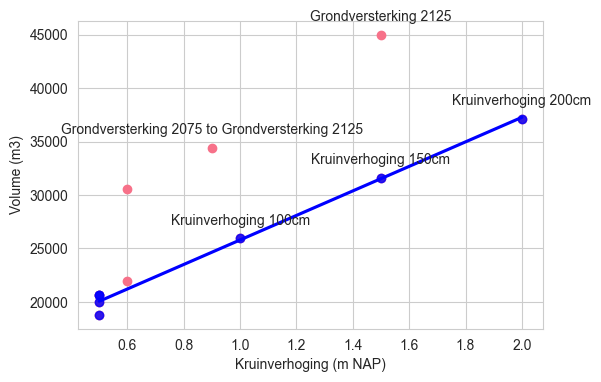

In [13]:


#compute sum of volumes for each alternative
for name, dimension in volume_cost_df_soil.iterrows():
    volume_cost_df_soil.loc[name, 'Volume (m3)'] = dimension['V1b'] + dimension['V2b'] + dimension['V3'] + dimension['V4'] + dimension['V5']

# volume_cost_df_soil['Kruinverhoging'] = [0.6, 1.5, 0.6, 0.9]
volume_cost_df_soil['Kruinverhoging'] = [0.6, 1.5, 
                                         0.5, 1.0, 1.5, 2.0, 
                                         0.6, 0.9,
                                         .5, .5, .5]


#plot volume vs cost
fig, ax = plt.subplots(figsize=(6,4))
ax.scatter(volume_cost_df_soil['Volume (m3)'], volume_cost_df_soil['Kosten (excl. BTW)'])
#add regression line
sns.regplot(x='Volume (m3)', y='Kosten (excl. BTW)', data=volume_cost_df_soil.loc[volume_cost_df_soil.index.str.contains("Kruinverhoging")], ax=ax, scatter=False, color='red',ci=None)
##get formula parameters of ax+b for fit
slope, intercept = np.polyfit(volume_cost_df_soil.loc[volume_cost_df_soil.index.str.contains("Kruinverhoging"), 'Volume (m3)'], volume_cost_df_soil.loc[volume_cost_df_soil.index.str.contains("Kruinverhoging"), 'Kosten (excl. BTW)'], 1)
print(f"y = {slope}x + {intercept}")
K_V_soil = (slope, intercept)
# y = 29.70483950495558x + 332322.15965743054
#plot line for old relation
ax.plot(volume_cost_df_soil['Volume (m3)'], 29.70483950495558*volume_cost_df_soil['Volume (m3)'] + 332322.15965743054, color='green', label='oude relatie')
#get volumes for each
fig, ax = plt.subplots(figsize=(6,4))
ax.scatter(volume_cost_df_soil['Kruinverhoging'], volume_cost_df_soil['Volume (m3)'])
#regression for measures with Kruinverhoging in name
sns.regplot(x='Kruinverhoging', y='Volume (m3)', data=volume_cost_df_soil.loc[volume_cost_df_soil.index.str.contains("Kruinverhoging")], ax=ax, scatter=True, color='blue',ci=None)
slope, intercept = np.polyfit(volume_cost_df_soil.loc[volume_cost_df_soil.index.str.contains("Kruinverhoging"), 'Kruinverhoging'], volume_cost_df_soil.loc[volume_cost_df_soil.index.str.contains("Kruinverhoging"), 'Volume (m3)'], 1)
print(f"y = {slope}x + {intercept}")
V_dh_soil = (slope, intercept)
#add labels for each point
for i, row in volume_cost_df_soil.iterrows():
    if row['Kruinverhoging'] > 0.6:
        ax.annotate(i, (row['Kruinverhoging'], row['Volume (m3)']), textcoords="offset points", xytext=(0,10), ha='center')
ax.set_xlabel('Kruinverhoging (m NAP)')
ax.set_ylabel('Volume (m3)')


Constructie

In [5]:
## SETTINGS ## 
files = ['ontwerpvarianten constructief/kostenoverzicht_damwand15m_verankerd.xlsx',
         'ontwerpvarianten constructief/kostenoverzicht 2a.xlsx',
         'ontwerpvarianten constructief/kostenoverzicht 2b.xlsx',
         'ontwerpvarianten constructief/kostenoverzicht_damwand15m_verankerd.xlsx',
         'ontwerpvarianten constructief/kostenoverzicht 3a.xlsx',
         'ontwerpvarianten constructief/kostenoverzicht 3b.xlsx',
         'ontwerpvarianten constructief/kostenoverzicht 3d.xlsx',
         'ontwerpvarianten constructief/kostenoverzicht 3d.xlsx',
         'ontwerpvariant grond gestacked/kostenoverzicht grond 3 aanlegprofiel.xlsx',
         ]

names = ["Verankerde damwand 2025",
         "Ophogen kruin + Taludverflauwing + Oplassen damwand 2075",
         "Ophogen kruin + Taludverflauwing + Plaatsen L-wanden 2075",
         "L-wand op kruin 2075",
         "Ophogen kruin + Oplassen + Buispalen bijplaatsen 2125",
         "Ophogen kruin + Plaatsen L-wanden 2125",
         "Ophogen kruin + Kistdam in binnenteen 2125",
         "Ophogen kruin + Kistdam in kruin + Afschrijven damwand 2125",
         "Grondversterking 2125",
         ]

#  unit prices for custom structures #TODO check and align values:
unit_prices = {'oplassen variabel per meter damwand per strekkende meter': 300, #o.b.v. prijzen korte damwand (zwaarder profiel). 
               'oplassen vaste kosten per strekkende meter': 280 * 1.5, #o.b.v. unit price stalen gording UNP240. Keer 1.5 voor extra complexiteit
               'L-wand 1.5 meter hoog per strekkende meter': 200, #o.b.v. kosten bij agri-beton.nl (keerwand 150x200x78)
               'Buispalen bijplaatsen per strekkende meter': (7000 / 2.8),  # EU/st / h.o.h. 7000 per buispaal, 2.8m per buispaal
               'Kistdam in binnenteen per strekkende meter':6000, #   Lev/aanbr. kistdam, AZ36, inheid. 15m (B=4m) kost 10000, daar halen we de bestaande damwand vanaf (4000)
               'Kistdam in kruin per strekkende meter': 13000, #  Lev/aanbr. kistdam, AZ36, inheid. 20m (B=4m)
               'Afbranden bestaande damwand per strekkende meter': 200,  #nog checken,
                }

 
alternatives = dict(zip(names, files))

dike = DikeModel(complexity = 'gemiddelde maatregel')

#load costs for all alternatives
cost_dataframes_per_alternative = {}
for name, file in alternatives.items():
    cost_dataframes_per_alternative[name] = pd.read_excel(working_dir / file, sheet_name='Kosten')

#dimensions for all alternatives
dimensions = {}
for name, df in cost_dataframes_per_alternative.items():
    dimensions[name] = get_dimensions_dict_from_df(df)

vaklengte = dimensions['Verankerde damwand 2025']['structure']['Vaklengte'].copy()
# #update costs to include the custom structure costs.
# for name, dimension in dimensions.items():
#     if name == "Ophogen kruin + Taludverflauwing + Oplassen damwand 2075":
#         lengte_oplassen = 3.5 #m, aannemend dat er 1 vak van 3.5m nodig is om de kruin te versterken, dit is mogelijk optimistisch
#         dimension['structure'] = {'Type': f'Oplassen damwand {lengte_oplassen} meter', 
#                                   'Vaklengte': vaklengte, 
#                                   'Eenheidsprijs': unit_prices['oplassen variabel per meter damwand per strekkende meter'] * lengte_oplassen + unit_prices['oplassen vaste kosten per strekkende meter']}
#     elif name == "Ophogen kruin + Taludverflauwing + Plaatsen L-wanden 2075":
#         aantal_wanden = 2
#         dimension['structure'] = {'Type': f'Plaatsen {aantal_wanden} L-wanden bij teen', 
#                                   'Vaklengte': vaklengte, 
#                                   'Eenheidsprijs': unit_prices['L-wand 1.5 meter hoog per strekkende meter'] * aantal_wanden}
#         pass
#     elif name == "L-wand op kruin 2075":
#         dimension['structure'] = {'Type': f'L-wand 1.5 meter hoog op kruin', 
#                                   'Vaklengte': vaklengte,
#                                     'Eenheidsprijs': unit_prices['L-wand 1.5 meter hoog per strekkende meter']}
#     elif name == "Ophogen kruin + Oplassen + Buispalen bijplaatsen 2125":
#         lengte_oplassen = 1.8
#         dimension['structure'] = {'Type': f'Oplassen damwand {lengte_oplassen} meter + Buispalen bijplaatsen',
#                                     'Vaklengte': vaklengte,
#                                     'Eenheidsprijs': unit_prices['oplassen variabel per meter damwand per strekkende meter'] * lengte_oplassen + unit_prices['oplassen vaste kosten per strekkende meter'] + unit_prices['Buispalen bijplaatsen per strekkende meter']}
#     elif name == "Ophogen kruin + Plaatsen L-wanden 2125":
#         aantal_wanden = 5
#         dimension['structure'] = {'Type': f'Plaatsen {aantal_wanden} L-wanden bij teen',
#                                     'Vaklengte': vaklengte,
#                                     'Eenheidsprijs': unit_prices['L-wand 1.5 meter hoog per strekkende meter'] * aantal_wanden}
#     elif name == "Ophogen kruin + Kistdam in binnenteen 2125":
#         dimension['structure'] = {'Type': f'Kistdam in binnenteen',
#                                     'Vaklengte': vaklengte,
#                                     'Eenheidsprijs': unit_prices['Kistdam in binnenteen per strekkende meter']}
#     elif name == "Ophogen kruin + Kistdam in kruin + Afschrijven damwand 2125":
#         dimension['structure'] = {'Type': f'Kistdam in kruin + Afschrijven damwand',
#                                     'Vaklengte': vaklengte,
#                                     'Eenheidsprijs': unit_prices['Kistdam in kruin per strekkende meter'] + unit_prices['Afbranden bestaande damwand per strekkende meter']}
#     elif name == "Grondversterking 2125":
#         dimension['structure'] = {'Type': f'Afbranden bestaande damwand',
#                                     'Vaklengte': vaklengte,
#                                     'Eenheidsprijs': unit_prices['Afbranden bestaande damwand per strekkende meter']}
#     else:
#         pass

#recomputation of plain costs for all alternatives
cost_summaries = {}
full_cost_dicts = {}
new_dimensions = {}
for name, dimension in dimensions.items():
    cost_summaries[name], full_cost_dicts[name], new_dimensions[name] = modified_cost_computation(dike, dimension)
    print(f"Kosten van beginsituatie naar {name}: €{cost_summaries[name]['Kosten excl. BTW'].sum():,.0f}")

df_all_costs = pd.concat(cost_summaries.values(), axis=1)
df_all_costs.columns = cost_summaries.keys()
#add (ruw) to the column names of df_all_costs
df_all_costs.columns = [col + " (ruw)" for col in df_all_costs.columns]

# df_all_costs.loc['Vastgoedkosten', 'Grondversterking 2125 (ruw)'] = 1300000 + 100 * (250*3) + 100 * (250*5)




Kosten van beginsituatie naar Verankerde damwand 2025: €4,809,912
Kosten van beginsituatie naar Ophogen kruin + Taludverflauwing + Oplassen damwand 2075: €616,177
Kosten van beginsituatie naar Ophogen kruin + Taludverflauwing + Plaatsen L-wanden 2075: €864,219
Kosten van beginsituatie naar L-wand op kruin 2075: €4,809,912
Kosten van beginsituatie naar Ophogen kruin + Oplassen + Buispalen bijplaatsen 2125: €815,815
Kosten van beginsituatie naar Ophogen kruin + Plaatsen L-wanden 2125: €998,204
Kosten van beginsituatie naar Ophogen kruin + Kistdam in binnenteen 2125: €1,031,335
Kosten van beginsituatie naar Ophogen kruin + Kistdam in kruin + Afschrijven damwand 2125: €1,031,335
Kosten van beginsituatie naar Grondversterking 2125: €2,125,449


In [6]:
volume_cost_df_soil

,V1b,V2b,V3,V4,V5,Kosten (excl. BTW),Volume (m3),Kruinverhoging
Grondversterking 2075,2758,11032,2758,7822,6184,1630445,30554.0,0.6
Grondversterking 2125,2994,11979,2994,9710,17320,2125449,44997.0,1.5
Kruinverhoging 50cm,1620,6481,1620,4926,5387,1027465,20034.0,0.5
Kruinverhoging 100cm,1658,6635,1658,5826,10161,1242817,25938.0,1.0
Kruinverhoging 150cm,1668,6674,1668,5953,15676,1441528,31639.0,1.5
Kruinverhoging 200cm,1687,6748,1687,6016,21013,1633826,37151.0,2.0
Grondversterking 2025 to Grondversterking 2075,2196,5530,2758,2291,9182,1400547,21957.0,0.6
Grondversterking 2075 to Grondversterking 2125,2758,7822,2994,1887,18958,1773154,34419.0,0.9
Kruinverhoging 50cm to Kruinverhoging 100cm,1620,4926,1658,900,9699,988419,18803.0,0.5
Kruinverhoging 100cm to Kruinverhoging 150cm,1658,5826,1668,126,11341,1039865,20619.0,0.5


y = 30.96815968449398x + 522445.2600644283
y = 3103.8556262157604x + 24037.342901900847


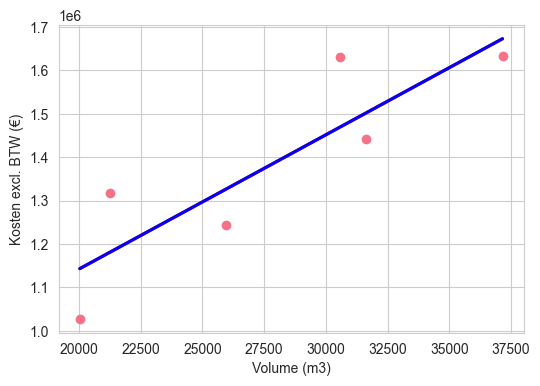

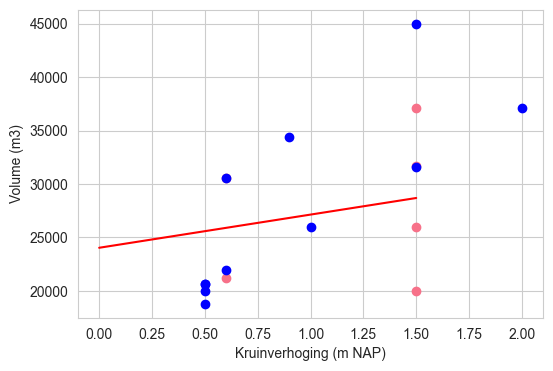

In [32]:
volume_total = {}
cost_total = {}
for name, dimension in new_dimensions.items():
    volume_total[name] = dimension['ground']['V1b'] + dimension['ground']['V2b'] + dimension['ground']['V3'] + dimension['ground']['V4'] + dimension['ground']['V5'] 
    cost_total[name] = cost_summaries[name]['Kosten excl. BTW'].sum()
#combine to dataframe

volume_cost_df_structure = pd.DataFrame({'Volume (m3)': volume_total, 'Kosten excl. BTW (€)': cost_total})
#rop Verankerde damwand en L-wand op kruin
volume_cost_df_structure = volume_cost_df_structure.drop(['Verankerde damwand 2025', 'L-wand op kruin 2075','Grondversterking 2125'], axis=0, errors='ignore')
volume_cost_df_structure

#plot volume vs cost
fig, ax = plt.subplots(figsize=(6,4))
ax.scatter(volume_cost_df_structure['Volume (m3)'], volume_cost_df_structure['Kosten excl. BTW (€)'])
#add regression line
sns.regplot(x='Volume (m3)', y='Kosten excl. BTW (€)', data=volume_cost_df_structure, ax=ax, scatter=False, color='red',ci=None)
#formula
slope, intercept = np.polyfit(volume_cost_df_structure['Volume (m3)'], volume_cost_df_structure['Kosten excl. BTW (€)'], 1)
print(f"y = {slope}x + {intercept}")
K_V_structure = (slope, intercept)

sns.regplot(x='Volume (m3)', y='Kosten excl. BTW (€)', data=volume_cost_df_structure, ax=ax, scatter=False, color='blue',ci=None)
#relatie kruin en volume:
volume_cost_df_structure['Kruinverhoging'] = [0.6, 0.6, 1.5, 1.5, 1.5, 1.5]

#get volumes for each
fig, ax = plt.subplots(figsize=(6,4))


ax.scatter(volume_cost_df_structure['Kruinverhoging'], volume_cost_df_structure['Volume (m3)'])
slope, intercept = np.polyfit(volume_cost_df_structure['Kruinverhoging'].tolist(),volume_cost_df_structure['Volume (m3)'].tolist(), 1)
V_dh_structure = (slope, intercept)
ax.plot(np.array([0]+ volume_cost_df_structure['Kruinverhoging'].tolist()), slope * np.array([0]+ volume_cost_df_structure['Kruinverhoging'].tolist()) + intercept, color='red', label='Fit line')
print(f"y = {slope}x + {intercept}")
ax.set_xlabel('Kruinverhoging (m NAP)')
ax.set_ylabel('Volume (m3)')
ax.scatter(volume_cost_df_soil['Kruinverhoging'], volume_cost_df_soil['Volume (m3)'], label='Grondversterking', color='blue')


## Uitwerking adaptatiepad


We gaan uit van een toename van de benodigde kruin van 1.8 cm/jaar als basisscenario. 
Daarin zit 0.3 cm/jaar als compensatie voor bodemdaling, en 1.5 cm/jaar voor ZSS.
In de scnearios kan dit laatste deel 50% sneller of 50% langzamer verlopen.

We beginnen in dit geval met een forse overhoogte: er hoeft pas in 2075 met 60 cm versterkt te worden voor zichtjaar 2125. 

Terugrekenend betekent dit dat 60 cm nodig is om 100 jaar bodemdaling = 30 cm plus 100 jaar ZSS  = 150 cm extra HBN te compenseren. 

Op dit moment is er dus een overhoogte van 120 centimeter.


Wanneer we kijken naar een constructie is de gangbare levensduur 100 jaar. We kijken naar een scenario met 50 jaar en 150 jaar levensduur van de verankerde damwand.
De investeringen in de damwand beschouwen we afzonderlijk.


In [33]:
ZSS_base_rate = 1.4
scenario_ZSS_cm_jaar = [ZSS_base_rate * .50, ZSS_base_rate, ZSS_base_rate * 1.5]
#round values to 1 decimal
scenario_ZSS_cm_jaar = [round(x, 1) for x in scenario_ZSS_cm_jaar]
lifespan = [50, 100, 150]
#voor aanvulling van grond bij de damwand rekenen we met een benaderingsformule (o.b.v. een fit op de doorgerekende maatregelen):
#Kosten per volume zijn K(V) = 45 * V + 20000
#Volume per meter verhoging is V(dH) = 13000 * dH + 2000

#per jaar kijken we of er een verhoging van de kruin nodig is. 

#daarnaast kijken we naar vervanging van de constructie: 
#bij een remaining life van < 20 jaar wordt de constructie vervangen door een kistdam. kosten zijn 5000000
kosten_damwand = 5000000
kosten_kistdam = 5000000
kosten_oplassen = 1800000
kosten_oplassen_buispalen = 3200000
#bij een remaining life van > 20 jaar wordt de constructie uitgebreid door op te lassen, al dan niet met buispalen (vanaf > 100 cm verhoging in totaal). 
# Zonder buisplaen kosten 1500000, met buispalen 3000000
h_0 = 100
dh_crest = 0.3
volumes = {}
structures = {}
costs = {}
overhoogtes = {}
crest_increases = {}
remaining_life = []
for ZSS_speed in scenario_ZSS_cm_jaar:
    print(f"Scenario ZSS snelheid: {ZSS_speed} cm/jaar")
    for life in lifespan:
        kistdam_aanwezig = False
        costs_made = [(0, kosten_damwand)] #initial costs for the first design (verankerde damwand)
        volumes_added = [(0, 0)]
        structures_made = [(0, 'Verankerde damwand')]
        crest_increase = [(0,0)]
        total_increase = 0
        overhoogte = [h_0]
        print(f"Scenario levensduur: {life} jaar")
        remaining_life.append(life)
        for t in np.arange(1, 175, 1):
            overhoogte.append(overhoogte[-1] - (dh_crest) - (ZSS_speed))
            remaining_life.append(remaining_life[-1] - 1)
            if overhoogte[-1] < 0:
                #break if already 3 measures have been taken
                if len(costs_made) >= 3:
                    break
                #increase crest with predicted value (we assume we know for sure wat SLR will be)
                dcrest = dh_crest * 50 + ZSS_speed * 50
                total_increase += dcrest
                overhoogte[-1] += dcrest
                #determine what needs to be done for structure
                if remaining_life[-1] < 20:
                    #replace structure with a (new) cofferdam
                    volumes_added.append((t, V_dh_structure[0]* (dcrest/100) +V_dh_structure[1]))
                    costs_made.append((t, K_V_structure[0] * volumes_added[-1][1] + K_V_structure[1] + kosten_kistdam))
                    remaining_life[-1] = 100
                    structures_made.append((t, 'Kistdam'))
                    print(f"In {t+2025} wordt de kruin verhoogd met {dcrest} cm en de constructie vervangen door een kistdam. Kosten: {costs_made[-1][1]:,.0f} euro")
                else:
                    #uitbreiden door oplassen, mogelijk met buispalen (bij > 100 cm verhoging in totaal, tot 200 cm). Anders kistdam. Als er al een kistdam is, gewoon oplassen
                    if (total_increase > 200) & (total_increase <= 300):
                        #oplassen met buispalen
                        volumes_added.append((t, V_dh_structure[0]* (dcrest/100) +V_dh_structure[1] ))
                        costs_made.append((t, K_V_structure[0] * volumes_added[-1][1] + K_V_structure[1] + kosten_oplassen_buispalen))
                        structures_made.append((t, 'Oplassen met buispalen'))
                        print(f"In {t+2025} wordt de kruin verhoogd met {dcrest} cm en de constructie uitgebreid door oplassen met buispalen. Kosten: {costs_made[-1][1]:,.0f} euro")
                    elif (total_increase > 300) & ('Kistdam' not in [s[1] for s in structures_made]):
                        #kistdam
                        volumes_added.append((t, V_dh_structure[0]* (dcrest/100) +V_dh_structure[1]))
                        costs_made.append((t, K_V_structure[0] * volumes_added[-1][1] + K_V_structure[1] + kosten_kistdam))
                        structures_made.append((t, 'Kistdam'))
                        remaining_life[-1] = 100
                        print(f"In {t+2025} wordt de kruin verhoogd met {dcrest} cm en de constructie vervangen door een kistdam. Kosten: {costs_made[-1][1]:,.0f} euro")
                    elif (total_increase > 300) & ('Kistdam' in [s[1] for s in structures_made]):
                        #gewoon oplassen, er is al een kistdam.
                        volumes_added.append((t, V_dh_structure[0]* (dcrest/100) +V_dh_structure[1] ))
                        costs_made.append((t, K_V_structure[0] * volumes_added[-1][1] + K_V_structure[1] + kosten_oplassen))
                        structures_made.append((t, 'Oplassen'))
                        print(f"In {t+2025} wordt de kruin verhoogd met {dcrest} cm en de kistdam uitgebreid door oplassen. Kosten: {costs_made[-1][1]:,.0f} euro")
                    else:
                        volumes_added.append((t, V_dh_structure[0]* (dcrest/100) +V_dh_structure[1] ))
                        costs_made.append((t, K_V_structure[0] * volumes_added[-1][1] + K_V_structure[1] + kosten_oplassen))
                        structures_made.append((t, 'Oplassen'))
                        print(f"In {t+2025} wordt de kruin verhoogd met {dcrest} cm en de constructie uitgebreid door oplassen. Kosten: {costs_made[-1][1]:,.0f} euro")
            elif remaining_life[-1] == 0:
                #replace structure with a cofferdam. Also increase the crest for a horizon of 50 years (we assume we know for sure what SLR will be)
                if len(costs_made) >= 3:
                    break
                dcrest = max(dh_crest * 50 + ZSS_speed * 50 - overhoogte[-1], 0)
                if dcrest > 0: #kistdam met extra kruinverhoging
                    total_increase += dcrest
                    volumes_added.append((t, V_dh_structure[0]* (dcrest/100) +V_dh_structure[1]))
                    costs_made.append((t, K_V_structure[0] * volumes_added[-1][1] + K_V_structure[1] + kosten_kistdam))
                    print(f"In {t+2025} wordt de constructie vervangen door een kistdam en de kruin verhoogd met {dcrest} cm. Kosten: {costs_made[-1][1]:,.0f} euro")
                    structures_made.append((t, 'Kistdam'))
                else: #kistdam zonder extra kruinverhoging
                    costs_made.append((t, kosten_kistdam))
                    volumes_added.append((t, 0))
                    print(f"In {t+2025} wordt de constructie vervangen door een kistdam. Kosten: {costs_made[-1][1]:,.0f} euro")
                    structures_made.append((t, 'Kistdam'))
                overhoogte[-1] += dcrest
                remaining_life[-1] = 100
            else:
                dcrest = 0
            if dcrest > 0:
                crest_increase.append((t, dcrest))
        crest_increases[(ZSS_speed, life)] = crest_increase
        costs[(ZSS_speed, life)] = costs_made
        volumes[(ZSS_speed, life)] = volumes_added
        structures[(ZSS_speed, life)] = structures_made
        overhoogtes[(ZSS_speed, life)] = overhoogte




Scenario ZSS snelheid: 0.7 cm/jaar
Scenario levensduur: 50 jaar
In 2075 wordt de constructie vervangen door een kistdam. Kosten: 5,000,000 euro
In 2125 wordt de kruin verhoogd met 50.0 cm en de constructie uitgebreid door oplassen. Kosten: 3,114,898 euro
Scenario levensduur: 100 jaar
In 2125 wordt de kruin verhoogd met 50.0 cm en de constructie vervangen door een kistdam. Kosten: 6,314,898 euro
In 2175 wordt de kruin verhoogd met 50.0 cm en de constructie uitgebreid door oplassen. Kosten: 3,114,898 euro
Scenario levensduur: 150 jaar
In 2125 wordt de kruin verhoogd met 50.0 cm en de constructie uitgebreid door oplassen. Kosten: 3,114,898 euro
In 2175 wordt de kruin verhoogd met 50.0 cm en de constructie vervangen door een kistdam. Kosten: 6,314,898 euro
Scenario ZSS snelheid: 1.4 cm/jaar
Scenario levensduur: 50 jaar
In 2075 wordt de constructie vervangen door een kistdam en de kruin verhoogd met 69.99999999999997 cm. Kosten: 6,334,122 euro
In 2126 wordt de kruin verhoogd met 85.0 cm en 

In [34]:
#compute LCC:
#{name: cost year lifespan}
lcc = {}
total_horizon = {}
for (ZSS_speed, life), cost_list in costs.items():
    lcc[(ZSS_speed, life)] = []
    total_horizon[(ZSS_speed, life)] = 0
    #get total horizon based on last investment
    if structures[(ZSS_speed, life)][-1][1] == 'Kistdam':
        total_horizon[(ZSS_speed, life)] = 2025 + cost_list[-1][0] + 50
    else:
        total_horizon[(ZSS_speed, life)] = 2025 + cost_list[-1][0] + 50

    for count, (year, cost) in enumerate(cost_list):
        #check in structures if there is a kistdam, if so, set lifespan to 100 years, else use 50.
        if structures[(ZSS_speed, life)][count][1] == 'Kistdam':
            lifespan = 100
        else:
            lifespan = 50
        
        lcc[(ZSS_speed, life)].append((year, compute_lcc({structures[(ZSS_speed, life)][count][1]: (cost, 2025 + year, lifespan)}, total_horizon = total_horizon[(ZSS_speed, life)])))
    # print(lcc[(ZSS_speed, life)])
    # print(total_horizon[(ZSS_speed, life)]-2025)

C:\Users\klerk_wj\AppData\Local\Temp\ipykernel_28568\2631806915.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{(y/1e6):.1f}" for y in ax.get_yticks()])
C:\Users\klerk_wj\AppData\Local\Temp\ipykernel_28568\2631806915.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{(y/1e6):.1f}" for y in ax.get_yticks()])
C:\Users\klerk_wj\AppData\Local\Temp\ipykernel_28568\2631806915.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{(y/1e6):.1f}" for y in ax.get_yticks()])


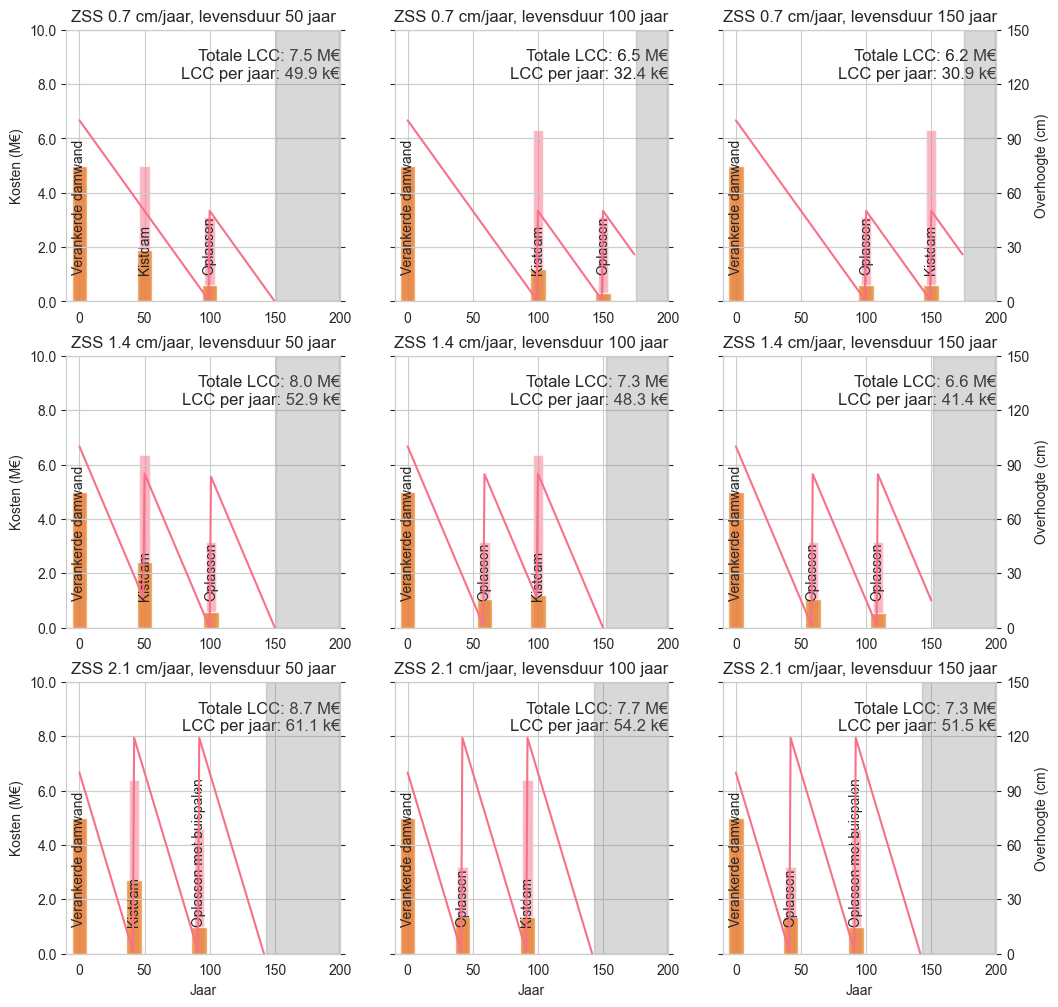

In [75]:
from matplotlib.ticker import MaxNLocator

def LCC_in_time_plot(ax_id, costs, lcc, overhoogtes, structures, total_horizon, scenario, **kwargs):

    ax = ax_id

    ax.bar([t for t, c in costs], [c for t, c in costs], label='Kosten', alpha=0.5, width=8)
    #lcc per jaar
    ax.bar([t for t, c in lcc], [list(c.values())[0] for t, c in lcc], label='LCC', alpha=0.8, width=12)

    #add lables fro structures
    if kwargs.get('measure_labels', True):
        for t, s in structures:
            ax.text(t, kwargs.get('text_y', 1e6), s, rotation=90, verticalalignment='bottom', horizontalalignment='center', fontsize=10,)
    ax.set_ylim(top=kwargs.get('ylim_cost_max', 15e6), bottom=0)
    ax.set_xlim(-10, 200)
    #add label with total LCC in M€
    #add twiny for hoogte
    ax2 = ax.twinx()
    ax2.plot(overhoogtes, label='Overhoogte')
    #make area beyond len(overhoogtes) shaded
    ax2.fill_between(range(len(overhoogtes), 200), 0, 150, color='grey', alpha=0.3, label = 'Niet doorgerekend')
    ax2.set_ylim(top=150, bottom=0)
    #get the number of yticks for ax and ensure ax2 has the same number of yticks
    ax.yaxis.set_major_locator(MaxNLocator(nbins=kwargs.get('grid_lines', 6)))
    ax2.yaxis.set_major_locator(MaxNLocator(nbins=kwargs.get('grid_lines', 6)))
    ax.set_title(f"ZSS {scenario[0]} cm/jaar, levensduur {scenario[1]} jaar")
    #only show yticklabels axfor plots in first column
    if i % 3 != 0:
        ax.set_yticklabels([])
    else:
        ax.set_yticklabels([f"{(y/1e6):.1f}" for y in ax.get_yticks()])
        ax.set_ylabel('Kosten (M€)')
    # onlyu show yticklabels of ax2 for plots in last column
    if i % 3 != 2:
        ax2.set_yticklabels([])
    else:
        ax2.set_ylabel('Overhoogte (cm)')
    #add label for bottom row
    if i >= 6:
        ax.set_xlabel('Jaar')
    ax.text(1.0, 0.93, f"Totale LCC: {sum([list(c.values())[0] for t, c in lcc])/1e6:.1f} M€\nLCC per jaar: {(sum([list(c.values())[0] for t, c in lcc])/1e3)/(total_horizon-2025):.1f} k€", transform=ax.transAxes, fontsize=12, verticalalignment='top', horizontalalignment='right')

fig,axes = plt.subplots(figsize=(12,12), ncols=3, nrows=3)
ax_ids = axes.flatten()

for i, (ZSS_speed, life) in enumerate(costs.keys()):
    scenario = (ZSS_speed, life)
    LCC_in_time_plot(ax_ids[i], costs[scenario], lcc[scenario], overhoogtes[scenario], structures[scenario], total_horizon[scenario], scenario, ylim_cost_max=10e6,grid_lines=5)

In [79]:
def compute_investment_cycles_soil(ZSS_speed, dh_crest, start_overhoogte, K_V, V_dh, number_of_investments = 3):
    t_grid = np.arange(0, 175, 1)
    overhoogte = [start_overhoogte]
    investments_made = 0
    costs_made = []
    volumes_added = []
    total_increase = 0
    total_horizon = t_grid[-1]
    for t in t_grid:
        overhoogte.append(overhoogte[-1] - (dh_crest) - (ZSS_speed))
        if overhoogte[-1] < 0:
            if investments_made >= number_of_investments:
                total_horizon = t
                break
            dcrest = dh_crest * 50 + ZSS_speed * 50
            total_increase += dcrest
            overhoogte[-1] += dcrest
            volume_added = V_dh[0]* (dcrest/100) +V_dh[1]
            cost_made = K_V[0] * volume_added + K_V[1]
            costs_made.append((t, cost_made))
            volumes_added.append((t, volume_added))
            investments_made += 1

    return costs_made, volumes_added, overhoogte,total_horizon

lcc_soil = {}
costs_soil = {}
volumes_soil = {}
overhoogtes_soil = {}
total_horizons_soil = {}
for ZSS_speed in scenario_ZSS_cm_jaar:
    costs_soil[ZSS_speed], volumes_soil[ZSS_speed], overhoogtes_soil[ZSS_speed], total_horizons_soil[ZSS_speed] = compute_investment_cycles_soil(ZSS_speed = ZSS_speed, dh_crest = 0.3, start_overhoogte = 100, K_V = K_V_soil, V_dh = V_dh_soil, number_of_investments = 3)
    #reorder investments to be good input for LCC computation: sort by year
    investment_list = {f'Grondversterking {count}': (cost, 2025+year, 50) for count, (year, cost) in enumerate(costs_soil[ZSS_speed])}
    lcc_list = compute_lcc(investment_list, total_horizon = total_horizons_soil[ZSS_speed])
    lcc_soil[ZSS_speed] = ([(costs_soil[ZSS_speed][count][0], {lcc[0]: lcc[1]}) for count, lcc in enumerate(lcc_list.items())])
    #add t=0 reinforcement:
    lcc_soil[ZSS_speed].insert(0, (0, {'Initiele grondversterking': df_all_costs_with_increments_soil['Grondversterking 2025 (ruw)'].sum() + 1300000})) #add vastgoedkosten
print(costs_soil)
print(lcc_soil)

{0.7: [(99, 1031350.9392269484), (149, 1031350.9392269484)], 1.4: [(58, 1173300.1388582734), (108, 1173300.1388582734), (158, 1173300.1388582734)], 2.1: [(41, 1315249.3384895984), (91, 1315249.3384895984), (141, 1315249.3384895984)]}
{0.7: [(0, {'Initiele grondversterking': 2617010.271998713}), (99, {'Grondversterking 0': 197786.20412188812}), (149, {'Grondversterking 1': 92047.88136199818})], 1.4: [(0, {'Initiele grondversterking': 2617010.271998713}), (58, {'Grondversterking 0': 397882.46895415825}), (108, {'Grondversterking 1': 198544.13124883902}), (158, {'Grondversterking 2': 93231.58875443142})], 2.1: [(0, {'Initiele grondversterking': 2617010.271998713}), (41, {'Grondversterking 0': 564935.6858367173}), (91, {'Grondversterking 1': 281904.0136418804}), (141, {'Grondversterking 2': 129996.59649560563})]}


C:\Users\klerk_wj\AppData\Local\Temp\ipykernel_28568\2631806915.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{(y/1e6):.1f}" for y in ax.get_yticks()])


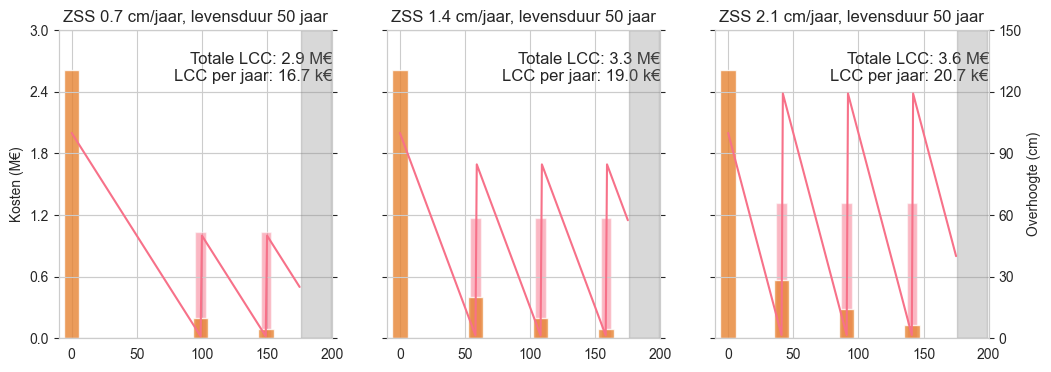

In [80]:
#plot LCC and costs for soil investments
fig, axes = plt.subplots(figsize=(12,4), ncols=3, nrows=1)
for i, ZSS_speed in enumerate(scenario_ZSS_cm_jaar):
    LCC_in_time_plot(axes[i], costs_soil[ZSS_speed], lcc_soil[ZSS_speed], overhoogtes_soil[ZSS_speed], [(t, f'Grondversterking {count}') for count, (t, c) in enumerate(costs_soil[ZSS_speed])], total_horizons_soil[ZSS_speed]+2025, (ZSS_speed, 50),ylim_cost_max=3e6,text_y=1e5,grid_lines=5,measure_labels=False)



In [147]:

lifespan = [50, 100, 150]
#plot heatmap of all LCC and LCC per year
#first make a dataframe with the total LCC and LCC per year for each scenario. Use ZSS as row and life as column

#FIRST FOR STRUCTURES:
lcc_df_structure = pd.DataFrame(index=[f"{ZSS_speed} cm/jaar" for ZSS_speed in scenario_ZSS_cm_jaar], columns=[f"{life} jaar" for life in lifespan])
lcc_per_year_df_structure = lcc_df_structure.copy()
#copy to lcc_per_year_df
lcc_per_year_df = lcc_df_structure.copy()
for i, (ZSS_speed, life) in enumerate(costs.keys()):
    lcc_df_structure.loc[f"{ZSS_speed} cm/jaar", f"{life} jaar"] = sum([list(c.values())[0] for t, c in lcc[(ZSS_speed, life)]])
    lcc_per_year_df_structure.loc[f"{ZSS_speed} cm/jaar", f"{life} jaar"] = (sum([list(c.values())[0] for t, c in lcc[(ZSS_speed, life)]]))/(total_horizon[(ZSS_speed, life)]-2025)

#THEN FOR SOIL:
lcc_soil_df = pd.DataFrame(index=[f"{ZSS_speed} cm/jaar" for ZSS_speed in scenario_ZSS_cm_jaar], columns=[f"{life}" for life in ['n.v.t.']])
lcc_per_year_soil_df = lcc_soil_df.copy()
for i, ZSS_speed in enumerate(scenario_ZSS_cm_jaar):
    lcc_soil_df.loc[f"{ZSS_speed} cm/jaar", f"n.v.t."] = sum([list(c.values())[0] for t, c in lcc_soil[ZSS_speed]])
    lcc_per_year_soil_df.loc[f"{ZSS_speed} cm/jaar", f"n.v.t."] = (sum([list(c.values())[0] for t, c in lcc_soil[ZSS_speed]]))/(total_horizons_soil[ZSS_speed])

lcc_df_structure = lcc_df_structure.astype(float)
lcc_per_year_df_structure = lcc_per_year_df_structure.astype(float)
lcc_soil_df = lcc_soil_df.astype(float)
lcc_per_year_soil_df = lcc_per_year_soil_df.astype(float)

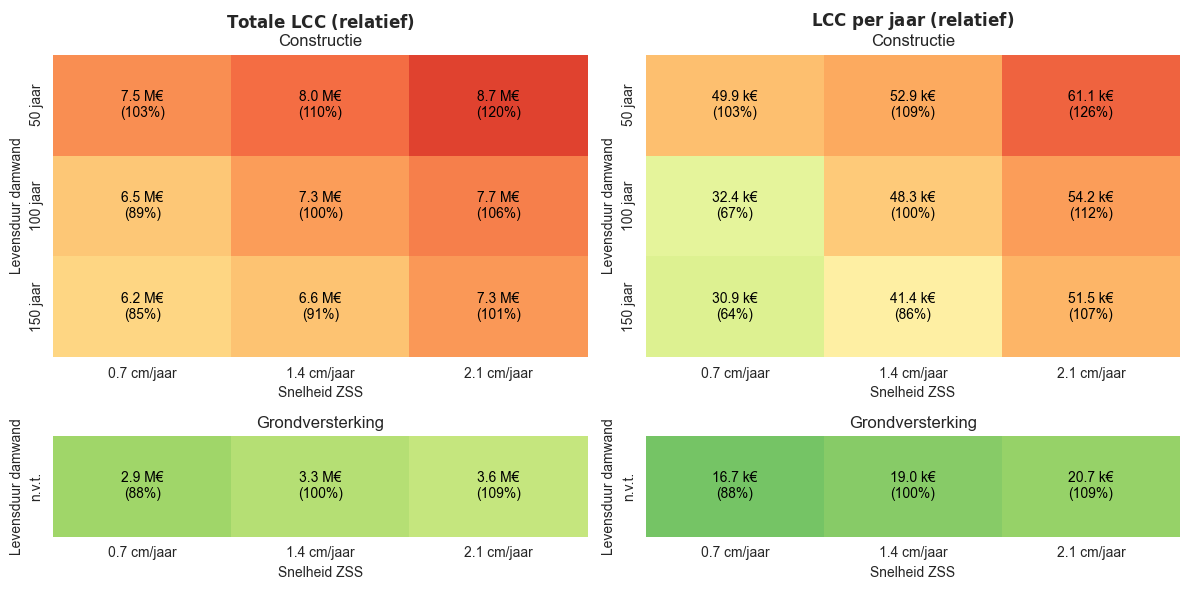

In [154]:
def plot_heatmap_lcc(lcc_df, normalization_value, ax_id, normalization_unit = 1e6, vmax = 10e6):
    ax = ax_id
    sns.heatmap(lcc_df.T, annot=False, cmap="RdYlGn_r", ax=ax, cbar=False, vmin=0.0, vmax=vmax)
    #add annotation from lcc_df with percentage in brackets on second line:
    for i in range(lcc_df.shape[0]):
        for j in range(lcc_df.shape[1]):
            if normalization_unit == 1e6:
                ax.text(i+0.5, j+0.5, f"{lcc_df.iloc[i,j]/1e6:,.1f} M€\n({lcc_df.iloc[i,j]/normalization_value:.0%})", ha='center', va='center', color='black')
            elif normalization_unit == 1e3:
                ax.text(i+0.5, j+0.5, f"{lcc_df.iloc[i,j]/1e3:,.1f} k€\n({lcc_df.iloc[i,j]/normalization_value:.0%})", ha='center', va='center', color='black')
            else:
                raise ValueError("Normalization value must be 1e6 or 1e3")
    ax.set_title(r"$\mathbf{Totale\ LCC\ (relatief)}$" + "\nConstructie")
    ax.set_xlabel("Snelheid ZSS")
    ax.set_ylabel("Levensduur damwand")


#plot the heatmaps
fig, axes = plt.subplots(figsize=(12,6), ncols=2, nrows=2, height_ratios=[3,1])

#use cmap green to red for lcc_df and blue to yellow for lcc_per_year_df

plot_heatmap_lcc(lcc_df_structure, lcc_df_structure.loc[f"{scenario_ZSS_cm_jaar[1]} cm/jaar", "100 jaar"], axes[0,0], vmax = 10e6)

plot_heatmap_lcc(lcc_per_year_df_structure, lcc_per_year_df_structure.loc[f"{scenario_ZSS_cm_jaar[1]} cm/jaar", "100 jaar"], axes[0,1], normalization_unit = 1e3, vmax = 75e3)

plot_heatmap_lcc(lcc_soil_df, lcc_soil_df.loc[f"{scenario_ZSS_cm_jaar[1]} cm/jaar", "n.v.t."], axes[1,0], vmax = 10e6)

plot_heatmap_lcc(lcc_per_year_soil_df, lcc_per_year_soil_df.loc[f"{scenario_ZSS_cm_jaar[1]} cm/jaar", "n.v.t."], axes[1,1], normalization_unit = 1e3, vmax = 75e3)

axes[0,0].set_title(r"$\mathbf{Totale\ LCC\ (relatief)}$" + "\nConstructie")
axes[0,1].set_title(r"$\mathbf{LCC\ per\ jaar\ (relatief)}$" + "\nConstructie")
axes[0,0].set_xlabel("Snelheid ZSS")
axes[0,1].set_xlabel("Snelheid ZSS")
axes[0,0].set_ylabel("Levensduur damwand")

axes[1,0].set_title("Grondversterking")
axes[1,1].set_title("Grondversterking")

fig.tight_layout()
